## Podsumowanie — Model Extended (features_extended.csv)

| | Base (23 cechy) | Extended (31 cech) |
|---|---|---|
| Najlepszy model | Random Forest | **Ridge** |
| CV R² | -0.065 | **+0.393** |
| CV RMSE | 103,275 PLN | **75,815 PLN** |

### Kluczowe wnioski
- Nowe cechy przestrzenne (`dist_nearest_client_m`, `nearest_client_revenue`) były decydujące
- Ridge przewyższył Random Forest przy większej liczbie cech
- Model wyjaśnia 39% wariancji przychodów — sensowny wynik przy 50 próbkach
- `nearest_client_revenue` — najsilniejszy pozytywny predyktor
- `dist_nearest_client_m` — najsilniejszy negatywny predyktor

In [1]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import os

load_dotenv()

PROCESSED_DIR = r"C:\Users\slast\OneDrive\Pulpit\geo_zadanie\01_data\procced"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

print("✅ Biblioteki załadowane")

c:\Users\slast\miniconda3\envs\GEO\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Biblioteki załadowane


In [2]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'features_extended.csv'))

feature_cols = [c for c in df.columns 
                if c not in ['location_id', 'lat', 'lng', 'monthly_revenue']]

X = df[feature_cols]
y = df['monthly_revenue']

print(f"✅ Dataset: {df.shape[0]} lokalizacji × {len(feature_cols)} cech")
print(f"\nNowe cechy (vs base):")
base_cols = ['signal_count', 'unique_users', 'peak_morning_signals', 'building_count',
             'total_building_area', 'avg_building_area', 'residential_count', 
             'commercial_count', 'building_density', 'pop_total', 'pop_households',
             'avg_hh_size', 'poi_bank', 'poi_bus_stop', 'poi_hospital', 'poi_mall',
             'poi_park', 'poi_pharmacy', 'poi_restaurant', 'poi_school', 'poi_total',
             'competitor_count', 'dist_nearest_competitor_m']
new_cols = [c for c in feature_cols if c not in base_cols]
for col in new_cols:
    print(f"  + {col}")

✅ Dataset: 50 lokalizacji × 31 cech

Nowe cechy (vs base):
  + residential_ratio
  + commercial_ratio
  + pop_density
  + peak_ratio
  + signals_per_user
  + dist_nearest_client_m
  + nearest_client_revenue
  + dist_nearest_poi_m


In [3]:
models = {
    'Ridge':         Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=5, random_state=42),
    'XGBoost':       xgb.XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.1, subsample=0.8, colsample_bytree=0.5, reg_alpha=1.0, reg_lambda=2.0, random_state=42, verbosity=0),
    'SVR':           Pipeline([('scaler', StandardScaler()), ('model', SVR(C=100, epsilon=0.1))])
}

results = []
for name, model in models.items():
    cv_r2   = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_rmse = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    results.append({
        'Model':     name,
        'CV R²':     cv_r2.mean().round(3),
        'CV R² std': cv_r2.std().round(3),
        'CV RMSE':   (-cv_rmse.mean()).round(0)
    })

df_results = pd.DataFrame(results).sort_values('CV R²', ascending=False)
print("✅ Porównanie modeli — features_extended.csv (31 cech):")
display(df_results)

✅ Porównanie modeli — features_extended.csv (31 cech):


,Model,CV R²,CV R² std,CV RMSE
0,Ridge,0.393,0.186,75815.0
2,XGBoost,0.339,0.199,79960.0
1,Random Forest,0.215,0.219,87453.0
3,SVR,-0.109,0.127,106313.0


Ridge jest teraz najlepszy z R² = 0.393 — model wyjaśnia 39% wariancji przychodów. To sensowny wynik przy 50 próbkach.
Nowe cechy które to spowodowały to prawdopodobnie dist_nearest_client_m i nearest_client_revenue — informacja o sieci własnej klienta była kluczowa.
Trenujemy Ridge na pełnym zbiorze i robimy SHAP:

In [4]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

best_model = Ridge(alpha=10.0)
best_model.fit(X_scaled, y)

print("✅ Ridge wytrenowany na pełnym zbiorze")
print(f"   CV R²: 0.393 (5-fold)")

✅ Ridge wytrenowany na pełnym zbiorze
   CV R²: 0.393 (5-fold)


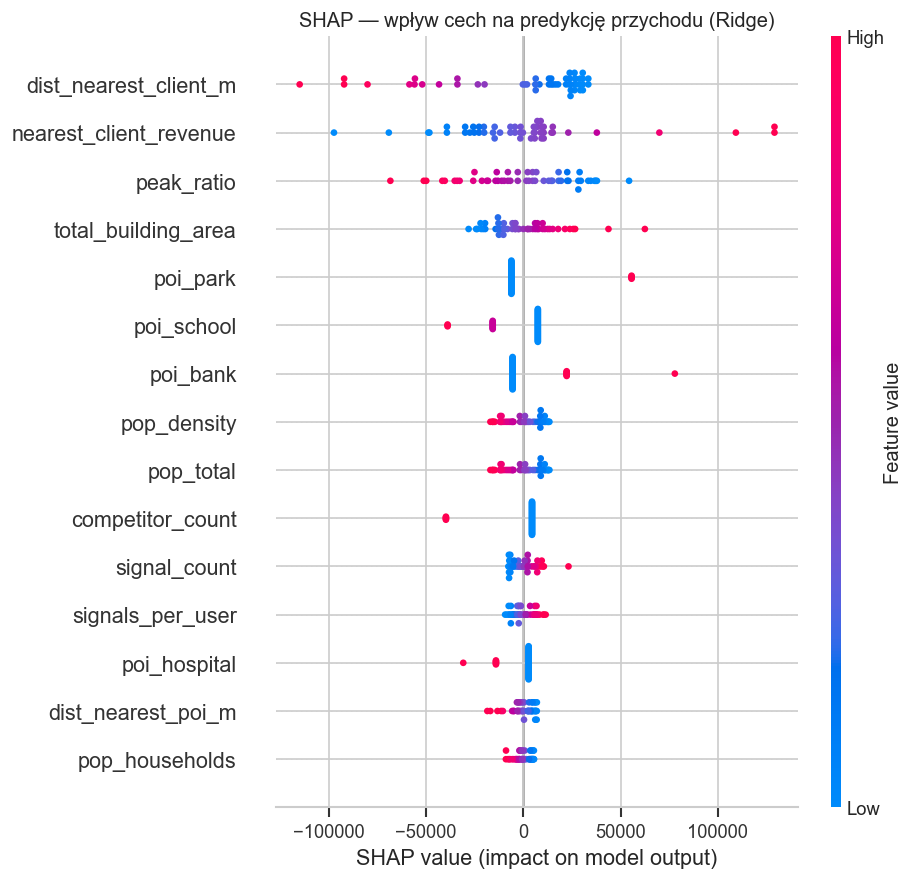

In [5]:
explainer = shap.LinearExplainer(best_model, X_scaled)
shap_values = explainer.shap_values(X_scaled)

shap.summary_plot(shap_values, X, show=False, max_display=15)
plt.title('SHAP — wpływ cech na predykcję przychodu (Ridge)')
plt.tight_layout()
plt.show()

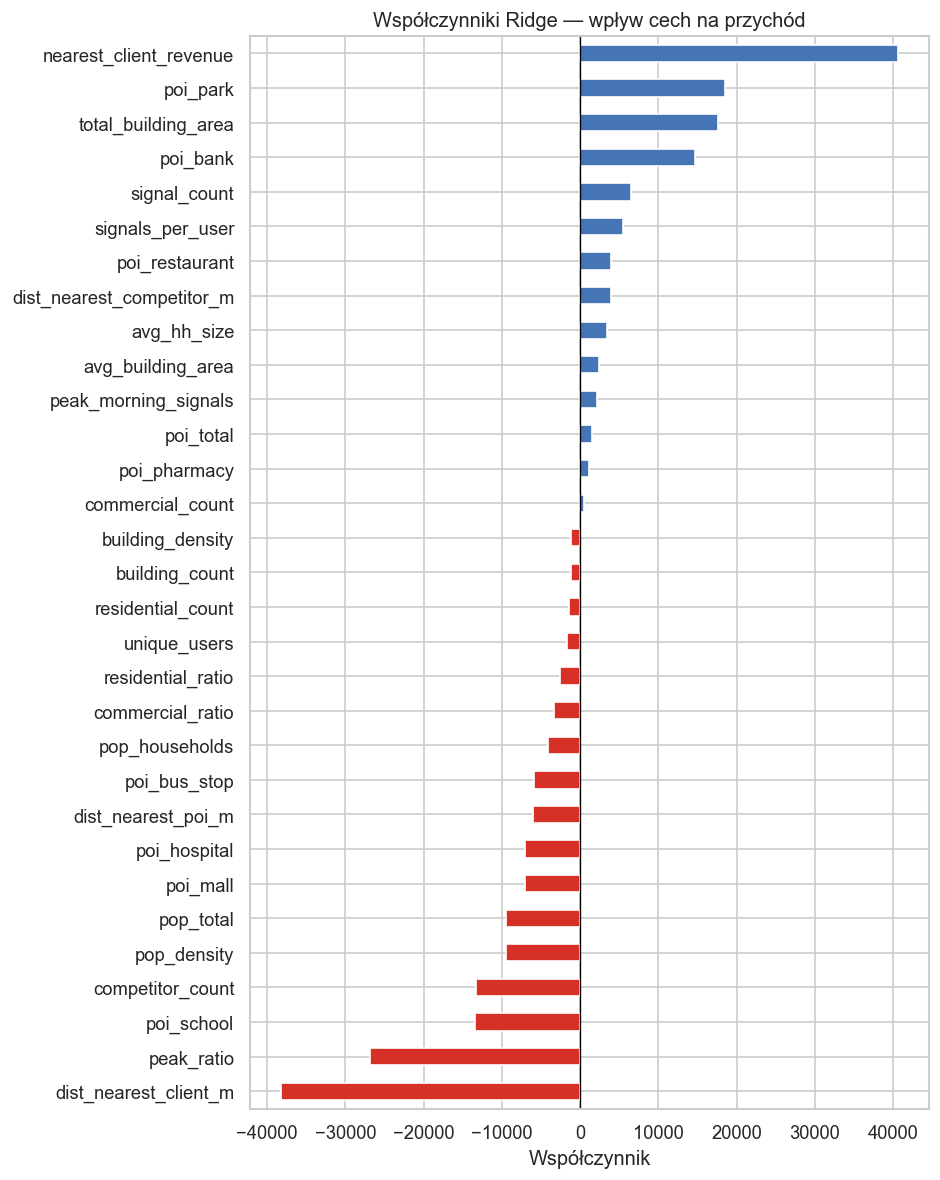

In [6]:
coefs = pd.Series(best_model.coef_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#d73027' if v < 0 else '#4575b4' for v in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Współczynniki Ridge — wpływ cech na przychód')
ax.set_xlabel('Współczynnik')
plt.tight_layout()
plt.show()